# **ARIMA regression**

Marek Šugár

In [1]:
import sys
import os

sys.path.append(os.path.abspath("../Model Kernels"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TrainingDataFrame

from sklearn.preprocessing import StandardScaler

# ML Stuff
import cvxpy as cp
import pmdarima


In [2]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

In [3]:
TrainingDataFrame["Time_flow"] = np.arange(1, len(TrainingDataFrame)+1)**2
historic_columns.append("Time_flow")

In [4]:
def markowitz(predicted_returns, lambda_risk, cov_matrix):
    '''
    Markowitz portfolio optimization implementation using cvxpy.
    predicted_returns: np.array of predicted returns for each asset
    lambda_risk: risk aversion parameter
    returns: optimal weights for each asset
    '''
    w = cp.Variable(len(predicted_returns))

    objective = cp.Maximize(predicted_returns @ w - lambda_risk * cp.quad_form(w, cov_matrix))

    constraints = [cp.sum(w) == 1, w >= 0]

    problem = cp.Problem(objective, constraints)
    problem.solve()

    return w.value

In [5]:
def markowitz_clean(weights, threshold=1e-6):
    '''
    Cleans the weights by setting very small weights to zero and re-normalizing.
    weights: np.array of weights
    threshold: minimum weight to keep
    returns: cleaned weights
    '''
    weights_cleaned = np.where(weights < threshold, 0, weights)
    if np.sum(weights_cleaned) > 0:
        weights_cleaned /= np.sum(weights_cleaned)
    return weights_cleaned

In [6]:
Stock_Data = pd.read_sql(f"SELECT Ticker, Date, Close FROM StockData ORDER BY Ticker", con=StockDataDatabase, parse_dates=["Date"])

prices_frame = Stock_Data.pivot(index="Date", columns="Ticker", values="Close").sort_index().ffill()
historical_returns = prices_frame.pct_change().dropna()

# **ARIMA regression**

In [7]:
all_data = {}

for ticker in tickers["Ticker"]:
    df = pd.read_sql(
        f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
        con=StockDataDatabase,
        parse_dates=["Date"]
    )
    df = pd.merge(df, TrainingDataFrame, on="Date")
    df["Target"] = df["Close"]
    df = df.dropna().reset_index(drop=True)
    all_data[ticker] = df

In [ ]:
training_length = 4
prediction_length = 1

dates = all_data[tickers["Ticker"].iloc[0]]["Date"]

portfolio_predictions = {}

for t in range(len(dates) - (training_length + prediction_length)):

    current_date = dates.iloc[t + training_length]
    portfolio_predictions[current_date] = {}

    for ticker, Stock_Data in all_data.items():

        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            Stock_Data[historic_columns].iloc[t:t+training_length]
        )
        y_train = Stock_Data["Target"].iloc[t:t+training_length]

        X_test = scaler.transform(
            Stock_Data[historic_columns].iloc[t+training_length:t+training_length+prediction_length]
        )

        MODEL = pmdarima.auto_arima(y=y_train, exogenous=X_train, seasonal=False, suppress_warnings=True)

        prediction = MODEL.predict(n_periods=prediction_length)

        pct_return = (prediction - Stock_Data["Close"].iloc[t+training_length-1]) / Stock_Data["Close"].iloc[t+training_length-1]

        portfolio_predictions[current_date][ticker] = pct_return

        print(f"Date: {current_date.date()}, Ticker: {ticker}, Prediction: {pct_return}")


In [10]:
snp = pd.read_sql("SELECT Date, Close FROM Indexes WHERE IndexName='S&P 500'", con=StockDataDatabase, parse_dates=["Date"])

snp["Return"] = snp["Close"].pct_change()

snp = snp.dropna()

In [11]:
nasdaq = pd.read_sql("SELECT Date, Close FROM Indexes WHERE IndexName='NASDAQ'", con=StockDataDatabase, parse_dates=["Date"])

nasdaq["Return"] = nasdaq["Close"].pct_change()
nasdaq = nasdaq.dropna()

In [14]:
initial_capital = 100

capital = initial_capital
capital_benchmark1 = initial_capital
capital_benchmark2 = initial_capital

portfolio_values = []
snp_values = []
nasdaq_values = []

weights_history = []

cov_window = 60
lambda_risk = 20

# start at max(cov_window, training_length)
t_start = max(cov_window, training_length)

for t in range(t_start, len(dates) - (training_length + prediction_length)):

    current_date = dates.iloc[t + training_length]

    # Covariance from last cov_window days
    covariance_data = historical_returns.loc[:current_date].tail(cov_window)
    cov_matrix = covariance_data.cov().values
    cov_matrix += 1e-6 * np.eye(cov_matrix.shape[0])  # stability

    # Predicted returns for next day
    predicted_returns = np.array(list(portfolio_predictions[current_date].values()))

    # Optimize weights
    optimal_weights = markowitz_clean(
        markowitz(predicted_returns, lambda_risk=lambda_risk, cov_matrix=cov_matrix)
    )

    # Realized returns next day
    next_day_index = t + training_length + prediction_length
    realized_r = historical_returns.iloc[next_day_index].values

    realized_bench = snp.iloc[next_day_index]["Return"]
    realized_nasdaq = nasdaq.iloc[next_day_index]["Return"]
    
    # Portfolio return & capital update
    portfolio_return = np.dot(optimal_weights, realized_r)
    capital *= (1 + portfolio_return)
    capital_benchmark1 *= (1 + realized_bench)
    capital_benchmark2 *= (1 + realized_nasdaq)

    # Save history
    portfolio_values.append(capital)
    weights_history.append(optimal_weights)

    snp_values.append(capital_benchmark1)
    nasdaq_values.append(capital_benchmark2)

    print(f"Date: {current_date + pd.Timedelta(days=1)}, Capital: {capital:.2f}")

# Optional: convert to np.array for plotting
portfolio_values = np.array(portfolio_values)
weights_history = np.array(weights_history)


ValueError: Incompatible dimensions (65, 1) (65, 1)

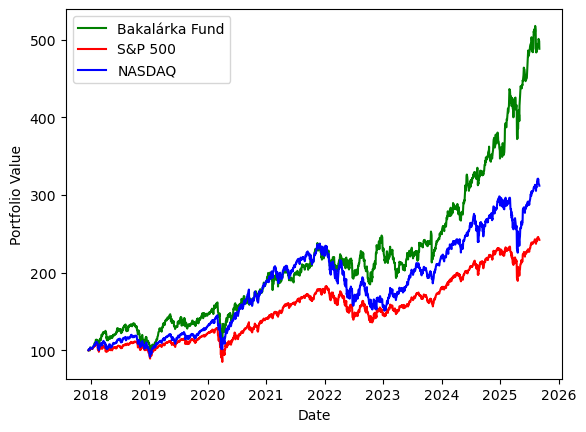

In [153]:
plt.plot(dates[65:], portfolio_values, c="green")
plt.plot(dates[65:], snp_values, c="red")
plt.plot(dates[65:], nasdaq_values, c="blue")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend(["Bakalárka Fund", "S&P 500", "NASDAQ"])

plt.show()

In [157]:
# Daily returns
portfolio_daily = portfolio_values[1:] / portfolio_values[:-1] - 1
benchmark_daily = np.array(snp_values[1:]) / np.array(snp_values[:-1]) - 1

# CAGR
trading_days = 252
years = len(portfolio_daily) / trading_days
cagr = (portfolio_values[-1] / portfolio_values[0]) ** (1/years) - 1
cagr_bench = (snp_values[-1] / snp_values[0]) ** (1/years) - 1

# Annualized volatility
vol = np.std(portfolio_daily) * np.sqrt(trading_days)
vol_bench = np.std(benchmark_daily) * np.sqrt(trading_days)

# Sharpe ratio (assume risk-free rate = 0)
sharpe = cagr / vol
sharpe_bench = cagr_bench / vol_bench

# Max drawdown
def max_drawdown(values):
    peak = values[0]
    max_dd = 0
    for v in values:
        if v > peak:
            peak = v
        dd = (peak - v) / peak
        if dd > max_dd:
            max_dd = dd
    return max_dd

mdd = max_drawdown(np.array(portfolio_values))
mdd_bench = max_drawdown(np.array(snp_values))

# % days beating benchmark
percent_better = np.mean(portfolio_daily > benchmark_daily) * 100

# Display
print(f"Portfolio CAGR: {cagr*100:.2f}%")
print(f"Portfolio Volatility: {vol*100:.2f}%")
print(f"Portfolio Sharpe Ratio: {sharpe:.2f}")
print(f"Portfolio Max Drawdown: {mdd*100:.2f}%")
print(f"S&P 500 Max Drawdown: {mdd_bench*100:.2f}%")
print(f"% of days portfolio beats S&P: {percent_better:.2f}%")


Portfolio CAGR: 22.94%
Portfolio Volatility: 24.76%
Portfolio Sharpe Ratio: 0.93
Portfolio Max Drawdown: 28.61%
S&P 500 Max Drawdown: 33.92%
% of days portfolio beats S&P: 52.12%
